<a href="https://colab.research.google.com/github/ADA-CompVision/SDP2022-brstcancer/blob/ralili/GAN/gan_models_test_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import argparse
import os
import numpy as np
import math
import sys

import torchvision.transforms as transforms
from torchvision.utils import save_image

from torch.utils.data import DataLoader, Dataset
from PIL import Image
from torchvision import datasets
from torch.autograd import Variable

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.autograd as autograd

In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

GPU available: True
GPU name: Tesla T4


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "gpu")

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rumiyyaalili","key":"ab121a81fb536037f0c3dd698d666bb2"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d theoviel/rsna-breast-cancer-256-pngs

Dataset URL: https://www.kaggle.com/datasets/theoviel/rsna-breast-cancer-256-pngs
License(s): CC0-1.0
 97% 973M/998M [00:08<00:00, 117MB/s]
100% 998M/998M [00:08<00:00, 127MB/s]


In [ ]:
!unzip -qq rsna-breast-cancer-256-pngs

In [ ]:
# Create directories
os.makedirs("images", exist_ok=True)

In [ ]:
import os

dataset_path = "/content"
extensions = (".png", ".jpg", ".jpeg")

# Count all image files recursively
total_images = 0
for root, _, files in os.walk(dataset_path):
    total_images += sum(file.lower().endswith(extensions) for file in files)

print(f"Total number of images in the dataset: {total_images}")

Total number of images in the dataset: 54706


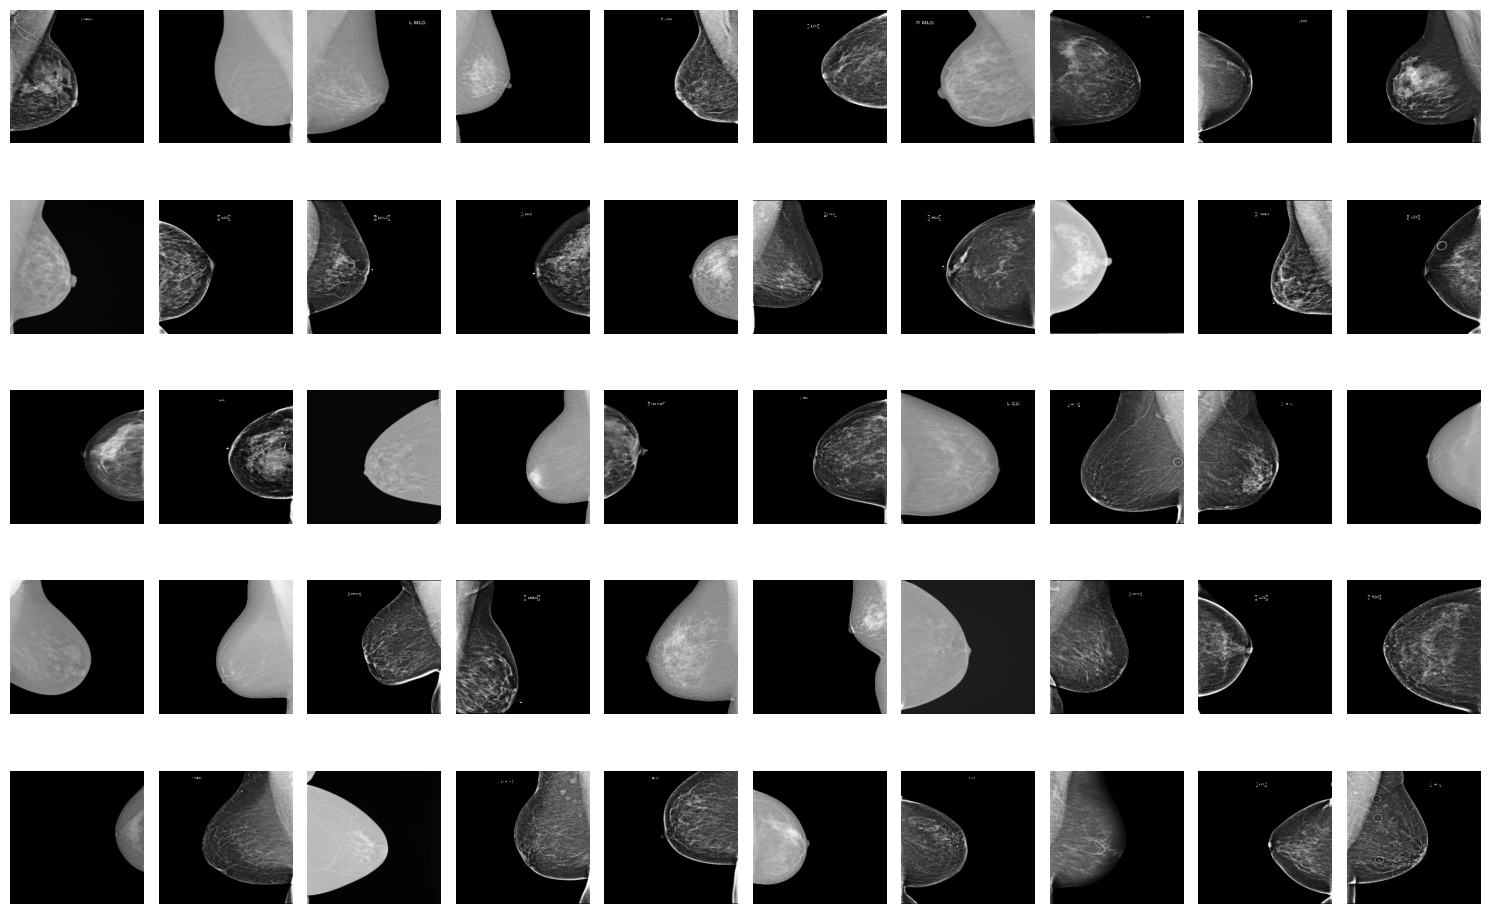

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

dataset_path = "/content"
extensions = (".png", ".jpg", ".jpeg")

# Get the first 50 image file paths
image_files = []
for root, _, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(extensions):
            image_files.append(os.path.join(root, file))
        if len(image_files) >= 50:  # Stop after collecting 50 images
            break
    if len(image_files) >= 50:
        break

# Display the first 50 images
fig, axes = plt.subplots(5, 10, figsize=(15, 10))  # Create a 5x10 grid
axes = axes.flatten()

for img_path, ax in zip(image_files, axes):
    img = Image.open(img_path).convert("L")  # Convert to grayscale
    ax.imshow(img, cmap="gray")  # Display as grayscale
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
from PIL import Image

# Paths
dataset_path = "/content"
aligned_dir = os.path.join(dataset_path, "aligned_images")
os.makedirs(aligned_dir, exist_ok=True)

def classify_breast(image):
    # Convert image to numpy array
    img_array = np.array(image)

    # Compute symmetry
    h, w = img_array.shape[:2]
    left_half = img_array[:, :w // 2]
    right_half = img_array[:, w // 2:]

    # Compute average pixel intensity (or other heuristics) for comparison
    left_mean = np.mean(left_half)
    right_mean = np.mean(right_half)

    # Example heuristic: If left side is brighter, it's a left breast image
    if left_mean > right_mean:
        return "LEFT"
    else:
        return "RIGHT"

In [ ]:
# Process images
for img_file in os.listdir(dataset_path):
    if img_file.endswith(".png"):
        img_path = os.path.join(dataset_path, img_file)

        image = Image.open(img_path).convert("L")

        # Classify the image
        label = classify_breast(image)

        # Flip the image if it's a left breast
        if label == "LEFT":
            image = image.transpose(Image.FLIP_LEFT_RIGHT)  # Horizontal flip

        # Save the aligned image
        aligned_path = os.path.join(aligned_dir, img_file)
        image.save(aligned_path)

print(f"Alignment complete. Aligned images are saved in '{aligned_dir}'.")

Alignment complete. Aligned images are saved in '/content/aligned_images'.


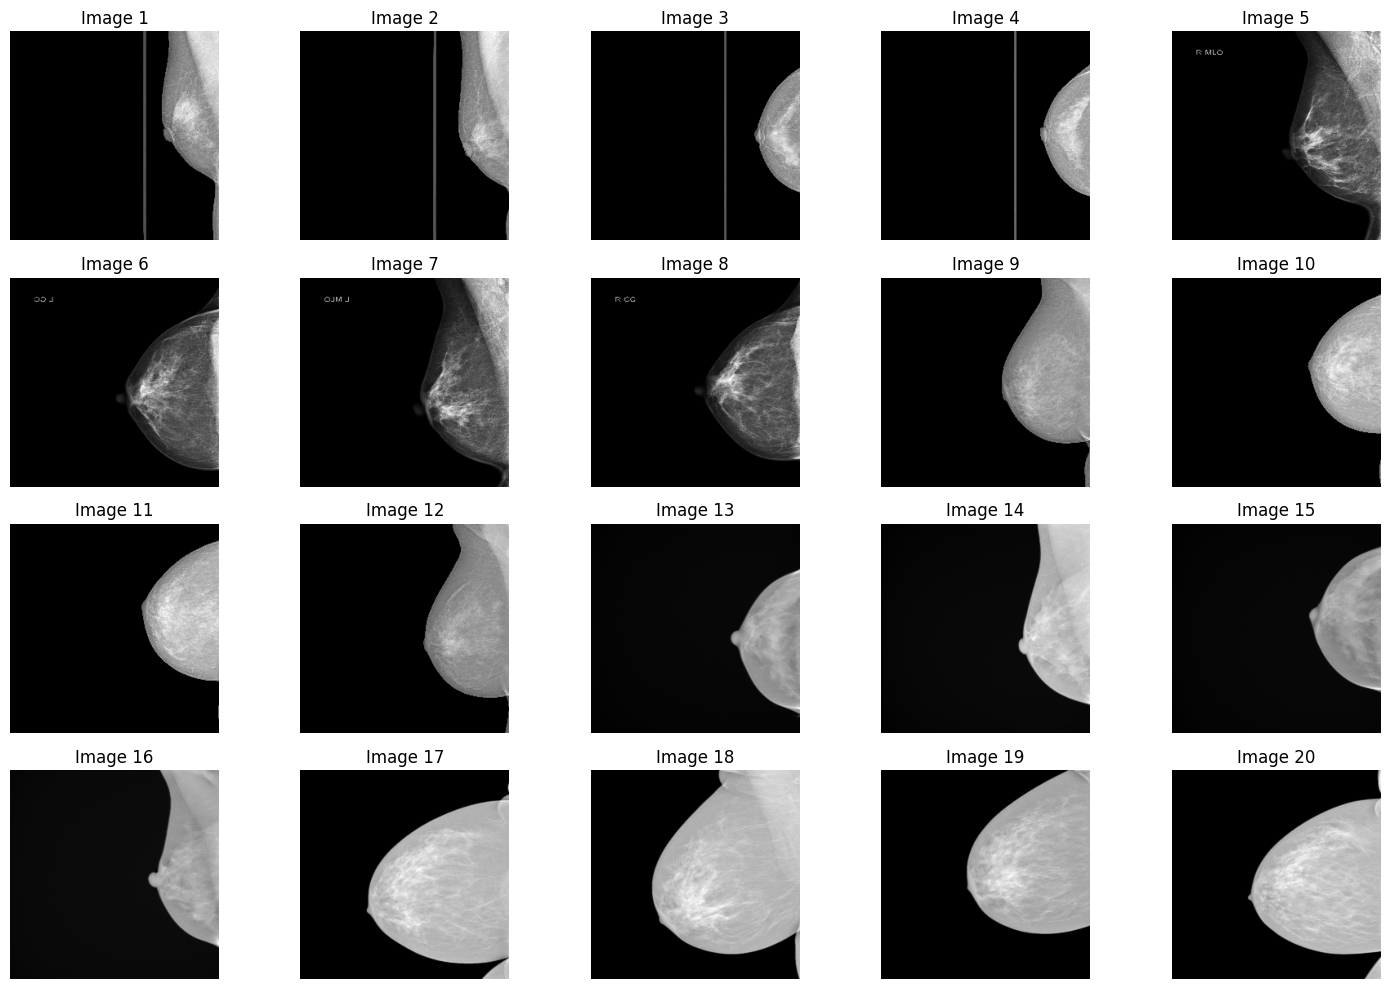

In [ ]:
# Directory with aligned images
aligned_dir = "/content/aligned_images"

# Get the first 20 images
image_files = [f for f in os.listdir(aligned_dir) if f.endswith(".png")]
image_files = sorted(image_files)[:20]  # Sort to ensure consistent order

# Plot the images
plt.figure(figsize=(15, 10))
for i, img_file in enumerate(image_files):
    img_path = os.path.join(aligned_dir, img_file)
    image = Image.open(img_path)

    # Display each image in a grid
    plt.subplot(4, 5, i + 1)  # 4 rows, 5 columns for 20 images
    plt.imshow(image, cmap="gray")
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Number of bright, high-contrast images: 12714


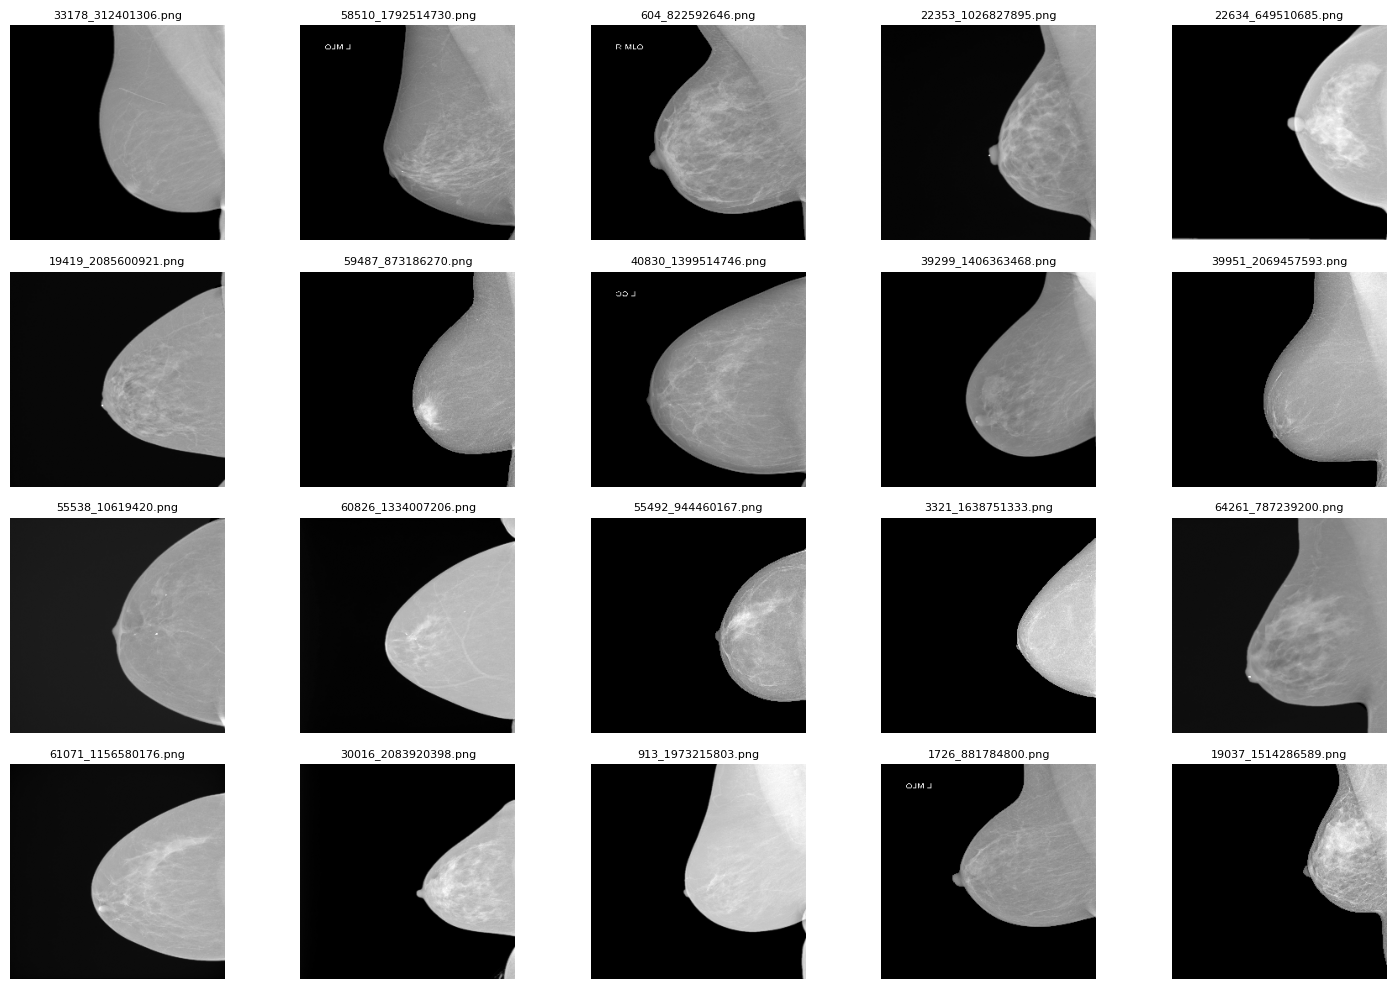

In [ ]:
dataset_dir = "/content/aligned_images"

# thresholds for detecting high-contrast and bright images
brightness_threshold = 0.5  # Pixels brighter than this are considered white - increase for very bright regions
region_brightness_ratio = 0.15  # Proportion of image that must be bright to qualify - decrease if missing images with smaller bright areas
contrast_threshold = 0.2  # Minimum contrast difference to identify bright regions - decrease to include images with slightly less contrast

# function to identify high-contrast, bright images
def find_bright_contrast_images(dataset_dir, brightness_threshold, region_brightness_ratio, contrast_threshold):
    bright_images = []
    bright_filenames = []

    for filename in os.listdir(dataset_dir):
        if filename.endswith((".png")):
            # Load image
            img_path = os.path.join(dataset_dir, filename)
            img = Image.open(img_path)

            # Normalize pixel values to [0, 1]
            img_array = np.array(img) / 255.0

            # Calculate overall contrast (difference between max and min pixel intensities)
            contrast = np.max(img_array) - np.min(img_array)

            # Identify bright pixels
            bright_pixels = img_array >= brightness_threshold
            bright_pixel_ratio = np.sum(bright_pixels) / img_array.size

            # Check conditions for bright and high-contrast images
            if contrast > contrast_threshold and bright_pixel_ratio > region_brightness_ratio:
                bright_images.append(img)
                bright_filenames.append(filename)

    return bright_images, bright_filenames

# Identify high-intensity and high-contrast images
bright_images, bright_filenames = find_bright_contrast_images(
    dataset_dir, brightness_threshold, region_brightness_ratio, contrast_threshold
)

# Print the number of bright, high-contrast images
print(f"Number of bright, high-contrast images: {len(bright_images)}")

# Display the first 20 bright images
num_to_display = min(20, len(bright_images))
plt.figure(figsize=(15, 10))
for i in range(num_to_display):
    plt.subplot(4, 5, i + 1)  # 4 rows x 5 columns
    plt.imshow(bright_images[i], cmap="gray")
    plt.title(bright_filenames[i], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Remove identified images from the dataset directory
for filename in bright_filenames:
    img_path = os.path.join(dataset_dir, filename)
    try:
        os.remove(img_path)  # Delete the file
        if random.randint(0,300) == 123:
          print(f"Deleted {filename}")
    except Exception as e:
        print(f"Error deleting {filename}: {e}")

# Print the total number of images remaining in the directory
remaining_images = [filename for filename in os.listdir(dataset_dir) if filename.endswith((".png"))]
print(f"Total number of images remaining: {len(remaining_images)}")

Streaming output truncated to the last 5000 lines.
Error deleting 61071_1839255698.png: name 'random' is not defined
Error deleting 63058_2143333130.png: name 'random' is not defined
Error deleting 49176_1538523389.png: name 'random' is not defined
Error deleting 61259_1075164519.png: name 'random' is not defined
Error deleting 7382_1457970325.png: name 'random' is not defined
Error deleting 3584_2055149305.png: name 'random' is not defined
Error deleting 7445_599528524.png: name 'random' is not defined
Error deleting 28671_313222584.png: name 'random' is not defined
Error deleting 57151_1516220965.png: name 'random' is not defined
Error deleting 62611_36730981.png: name 'random' is not defined
Error deleting 9392_1304185438.png: name 'random' is not defined
Error deleting 36925_587137902.png: name 'random' is not defined
Error deleting 62611_100714331.png: name 'random' is not defined
Error deleting 44756_754620303.png: name 'random' is not defined
Error deleting 61829_1056062773.png:

In [ ]:
# Set parameters
n_epochs = 100  # Number of epochs of training
batch_size = 64  # Size of the batches
lr_g = 0.001  # Adam: learning rate for generator
lr_d = 0.001 # learning rate for discriminator
b1 = 0.9  # Adam: decay of first-order momentum of gradient
b2 = 0.999  # Adam: decay of second-order momentum of gradient
latent_dim = 256  # Dimensionality of the latent space
img_size = 256  # Size of each image dimension
channels = 1  # Number of image channels (grayscale)
n_critic = 10  # Number of training steps for discriminator per iteration
clip_value = 0.01  # Lower and upper clip values for discriminator weights
sample_interval = 400  # Interval between image samples
lambda_gp = 10.0 # Define the gradient penalty weight

In [ ]:
img_shape = (channels, img_size, img_size)
cuda = True if torch.cuda.is_available() else False

In [ ]:
import torch.nn as nn
import numpy as np

class Generator(nn.Module):
    def __init__(self, latent_dim, img_shape):
        super(Generator, self).__init__()
        self.img_shape = img_shape  # Expected shape: (channels, height, width)
        self.channels = img_shape[0]  # Extract channels

        def block(in_feat, out_feat, normalize=True):
            layers = [nn.Linear(in_feat, out_feat)]
            if normalize:
                layers.append(nn.BatchNorm1d(out_feat, 0.8))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        # Fully connected part
        self.model_fc = nn.Sequential(
            *block(latent_dim, 128, normalize=False),
            *block(128, 256),
            *block(256, 512),
            *block(512, 1024),
            nn.Linear(1024, int(np.prod(img_shape))),
            nn.Tanh()
        )

        # Convolutional refinement part
        self.conv_refine = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        # Generate image from latent vector
        img = self.model_fc(z)

        # Ensure correct shape: (batch_size, channels, height, width)
        img = img.view(img.shape[0], self.channels, self.img_shape[1], self.img_shape[2])

        # Apply CNN refinement
        img = self.conv_refine(img)

        return img

In [ ]:
import torch
import torch.nn as nn

class Discriminator(nn.Module):
    def __init__(self, img_shape):
        super(Discriminator, self).__init__()
        self.img_shape = img_shape  # (channels, height, width)

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
        )

        # Dynamically calculate the flattened feature size
        self.flattened_size = self._get_flattened_size()

        self.fc_layers = nn.Sequential(
            nn.Linear(self.flattened_size, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1)  # Output a single value (real/fake)
        )

    def _get_flattened_size(self):
        """ Forward pass a dummy tensor to compute the flattened size dynamically. """
        with torch.no_grad():
            dummy_input = torch.zeros(1, *self.img_shape)  # Shape: (1, C, H, W)
            dummy_out = self.conv_layers(dummy_input)
            return int(torch.prod(torch.tensor(dummy_out.shape[1:])))  # Compute flattened size

    def forward(self, img):
        features = self.conv_layers(img)  # Apply convolutional layers
        features_flat = features.view(features.shape[0], -1)  # Flatten
        validity = self.fc_layers(features_flat)  # Fully connected layers
        return validity

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Directory of the dataset
dataset_dir = "/content/aligned_images"

# Custom Dataset Class to load images with on-the-fly augmentations
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith('.png')]  # Filter PNG files

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_name).convert('L')  # Convert to Grayscale (1 channel)

        if self.transform:
            image = self.transform(image)

        return image

# Define on-the-fly augmentation pipeline
transform = transforms.Compose([
    transforms.RandomRotation(degrees=15),  # Randomly rotate between -15° and 15°
    transforms.CenterCrop(224),  # Center crop
    transforms.Resize(256),  # Resize back to 256x256
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize([0.5], [0.5])  # Normalize grayscale images to [-1, 1]
])

# Create Dataset and DataLoader
dataset = CustomImageDataset(root_dir=dataset_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Test one batch to check transformations
for batch in dataloader:
    print(batch.shape)  # Expected: (32, 1, 256, 256) for grayscale images
    break

torch.Size([32, 1, 256, 256])


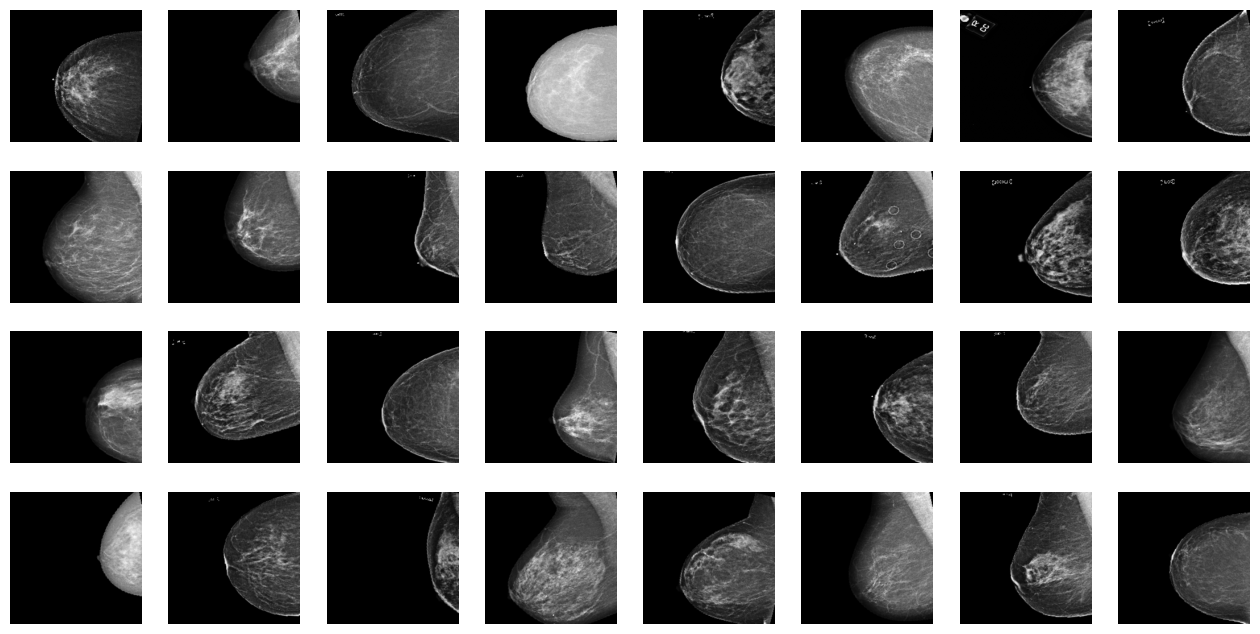

In [ ]:
import matplotlib.pyplot as plt
import torch

# Function to unnormalize image
def unnormalize(tensor, mean, std):
    """
    Unnormalize the tensor to the range [0, 1].
    """
    mean = torch.tensor(mean).view(-1, 1, 1)
    std = torch.tensor(std).view(-1, 1, 1)
    return tensor * std + mean

# Visualizing one batch of images
def visualize_batch(dataloader):
    # Get one batch from the dataloader
    batch = next(iter(dataloader))  # Get one batch

    # Handle different dataloader formats (with/without labels)
    if isinstance(batch, (list, tuple)):
        images = batch[0]  # Extract images if labels exist
    else:
        images = batch  # If there are no labels, the batch is just images

    # Unnormalize the images (since you used Normalize([0.5], [0.5]))
    images = unnormalize(images, mean=[0.5], std=[0.5])

    # Plot the images in the batch
    batch_size = images.size(0)
    fig, axes = plt.subplots(4, 8, figsize=(16, 8))  # Adjust grid size to display 32 images (4x8 grid)

    for i in range(min(batch_size, 32)):  # Limit to 32 images for display
        ax = axes[i // 8, i % 8]  # Find the correct subplot position
        ax.imshow(images[i].squeeze(), cmap='gray')  # Remove the channel dimension and display as grayscale
        ax.axis('off')  # Hide axes

    plt.show()

# Call function to visualize batch (make sure 'dataloader' is defined)
visualize_batch(dataloader)

In [ ]:
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch

def generate_and_display_images(generator, num_images=25, latent_dim=100, nrow=5, device="cuda"):
    """
    Generate and display images using the trained generator.

    Args:
        generator (nn.Module): The trained generator model.
        num_images (int): Number of images to generate.
        latent_dim (int): Dimensionality of the latent space.
        nrow (int): Number of images per row in the grid.
        device (str): Device to perform computations on ("cuda" or "cpu").
    """
    generator.eval()  # Set generator to evaluation mode
    with torch.no_grad():  # No need to compute gradients
        # Generate latent vectors
        z = torch.randn(num_images, latent_dim).to(device)
        # Generate images
        generated_images = generator(z)

        # Debug: Print shape of generated images
        print("Generated images shape:", generated_images.shape)

        # Remove any extra dimensions if necessary
        if generated_images.dim() == 5:  # Check if there's an extra dimension
            generated_images = generated_images.squeeze(2)

        # Normalize and move to CPU for display
        generated_images = generated_images.cpu()

        # Display images using a grid
        grid = make_grid(generated_images, nrow=nrow, normalize=True)
        plt.figure(figsize=(10, 10))
        plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
        plt.axis("off")
        plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Generated images shape: torch.Size([7, 1, 256, 256])


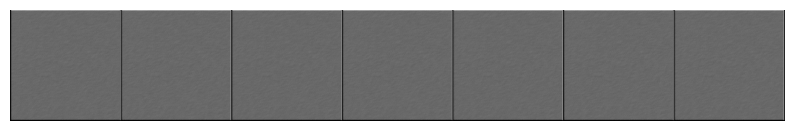

[Epoch 1/200] [D loss: -92.516266] [G loss: -229.616333]
[Epoch 2/200] [D loss: -112.082634] [G loss: -97.548447]
[Epoch 3/200] [D loss: -70.957680] [G loss: -59.022182]
[Epoch 4/200] [D loss: -72.587402] [G loss: -47.889694]
[Epoch 5/200] [D loss: -63.597321] [G loss: -50.487091]
Generated images shape: torch.Size([7, 1, 256, 256])


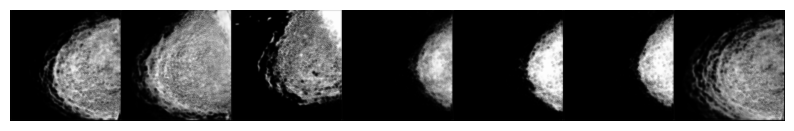

[Epoch 6/200] [D loss: -58.702637] [G loss: -30.678490]
[Epoch 7/200] [D loss: -39.972801] [G loss: 10.077145]
[Epoch 8/200] [D loss: -63.008171] [G loss: -10.386917]
[Epoch 9/200] [D loss: -65.361351] [G loss: -49.976597]
[Epoch 10/200] [D loss: -32.412540] [G loss: -14.232497]
Generated images shape: torch.Size([7, 1, 256, 256])


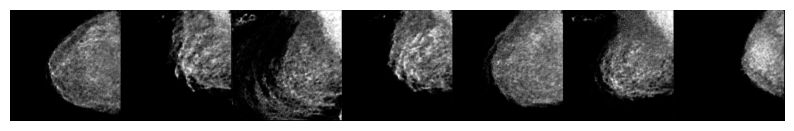

[Epoch 11/200] [D loss: -39.403214] [G loss: -40.900299]
[Epoch 12/200] [D loss: -46.565552] [G loss: -14.648284]
[Epoch 13/200] [D loss: -57.318733] [G loss: -2.095830]
[Epoch 14/200] [D loss: -40.134689] [G loss: -27.497604]
[Epoch 15/200] [D loss: -37.099281] [G loss: 6.418664]
Generated images shape: torch.Size([7, 1, 256, 256])


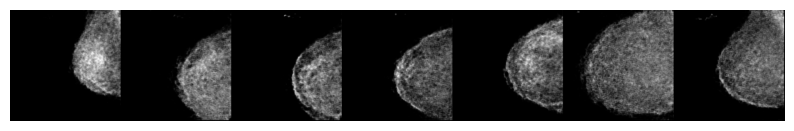

[Epoch 16/200] [D loss: -40.364258] [G loss: -24.303364]
[Epoch 17/200] [D loss: -32.466492] [G loss: -24.938957]
[Epoch 18/200] [D loss: -38.971573] [G loss: -27.968555]
[Epoch 19/200] [D loss: -48.227978] [G loss: -28.683563]
[Epoch 20/200] [D loss: -52.080711] [G loss: -15.709803]
Generated images shape: torch.Size([7, 1, 256, 256])


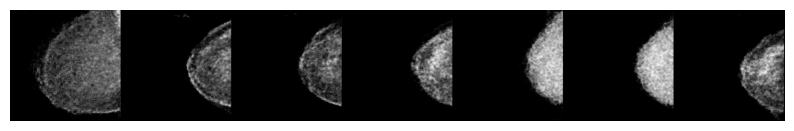

[Epoch 21/200] [D loss: -41.506630] [G loss: 23.019587]
[Epoch 22/200] [D loss: -29.389408] [G loss: -11.272447]
[Epoch 23/200] [D loss: -36.696514] [G loss: -4.034738]
[Epoch 24/200] [D loss: -38.061180] [G loss: -36.533520]
[Epoch 25/200] [D loss: -36.974182] [G loss: -24.186657]
Generated images shape: torch.Size([7, 1, 256, 256])


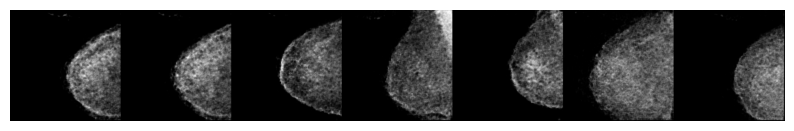

[Epoch 26/200] [D loss: -44.178017] [G loss: -15.336351]
[Epoch 27/200] [D loss: -44.021362] [G loss: -14.534826]
[Epoch 28/200] [D loss: -39.813187] [G loss: -3.176600]
[Epoch 29/200] [D loss: -28.183342] [G loss: -11.681519]
[Epoch 30/200] [D loss: -36.249149] [G loss: -12.739946]
Generated images shape: torch.Size([7, 1, 256, 256])


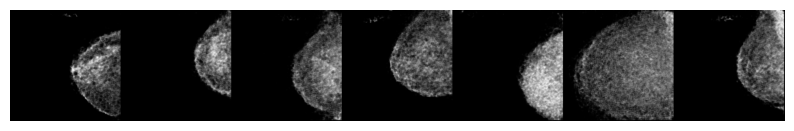

[Epoch 31/200] [D loss: -38.093971] [G loss: 18.787708]
[Epoch 32/200] [D loss: -35.552185] [G loss: 3.404488]
[Epoch 33/200] [D loss: -31.943611] [G loss: -6.652627]
[Epoch 34/200] [D loss: -41.229328] [G loss: -30.176323]
[Epoch 35/200] [D loss: -38.199158] [G loss: -17.304192]
Generated images shape: torch.Size([7, 1, 256, 256])


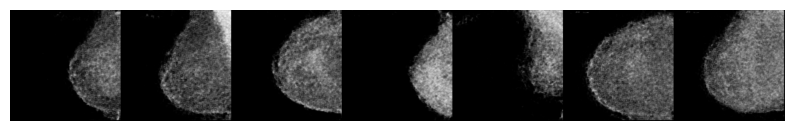

[Epoch 36/200] [D loss: -29.703098] [G loss: -21.787365]
[Epoch 37/200] [D loss: -23.821148] [G loss: -30.188183]
[Epoch 38/200] [D loss: -50.326145] [G loss: -26.529411]
[Epoch 39/200] [D loss: -37.804497] [G loss: 3.063401]
[Epoch 40/200] [D loss: -32.699219] [G loss: -17.536983]
Generated images shape: torch.Size([7, 1, 256, 256])


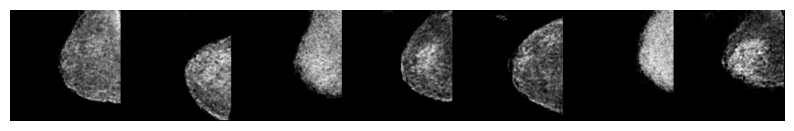

[Epoch 41/200] [D loss: -44.734734] [G loss: -8.018887]
[Epoch 42/200] [D loss: -38.348068] [G loss: -5.482435]
[Epoch 43/200] [D loss: -39.890625] [G loss: -20.045341]
[Epoch 44/200] [D loss: -37.268330] [G loss: -3.588657]
[Epoch 45/200] [D loss: -39.034550] [G loss: -9.052944]
Generated images shape: torch.Size([7, 1, 256, 256])


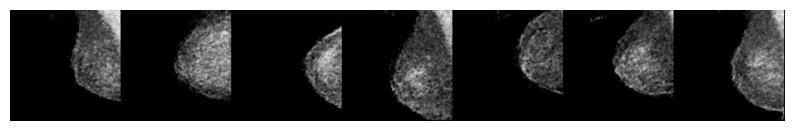

[Epoch 46/200] [D loss: -24.030525] [G loss: -38.592583]
[Epoch 47/200] [D loss: -42.952980] [G loss: -22.318645]
[Epoch 48/200] [D loss: -52.726337] [G loss: -21.590969]
[Epoch 49/200] [D loss: -23.117054] [G loss: -51.754097]
[Epoch 50/200] [D loss: -45.720741] [G loss: -28.305302]
Generated images shape: torch.Size([7, 1, 256, 256])


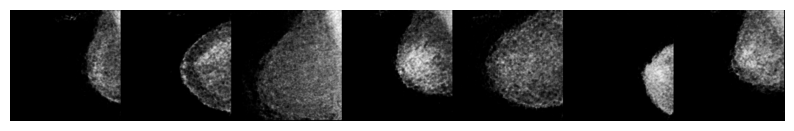

[Epoch 51/200] [D loss: -41.282158] [G loss: -25.697533]
[Epoch 52/200] [D loss: -50.911423] [G loss: -14.185635]
[Epoch 53/200] [D loss: -25.283863] [G loss: -10.991575]
[Epoch 54/200] [D loss: -36.687378] [G loss: -1.164192]
[Epoch 55/200] [D loss: -42.555264] [G loss: -27.576920]
Generated images shape: torch.Size([7, 1, 256, 256])


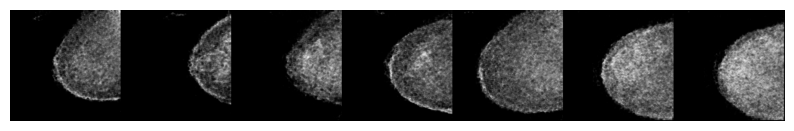

[Epoch 56/200] [D loss: -32.161026] [G loss: 6.684138]
[Epoch 57/200] [D loss: -63.193272] [G loss: 17.643545]
[Epoch 58/200] [D loss: -54.805183] [G loss: -46.958397]
[Epoch 59/200] [D loss: -36.666965] [G loss: -14.142302]
[Epoch 60/200] [D loss: -33.529465] [G loss: -7.954976]
Generated images shape: torch.Size([7, 1, 256, 256])


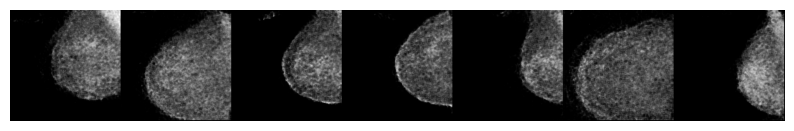

[Epoch 61/200] [D loss: -40.785431] [G loss: -29.819355]
[Epoch 62/200] [D loss: -50.780090] [G loss: -16.424953]
[Epoch 63/200] [D loss: -40.564857] [G loss: -24.916210]
[Epoch 64/200] [D loss: -41.031853] [G loss: -36.484131]
[Epoch 65/200] [D loss: -38.713654] [G loss: -10.193993]
Generated images shape: torch.Size([7, 1, 256, 256])


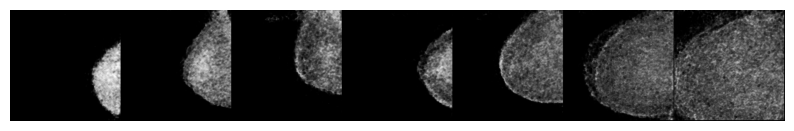

[Epoch 66/200] [D loss: -32.273674] [G loss: -23.279102]
[Epoch 67/200] [D loss: -44.071247] [G loss: -2.697944]
[Epoch 68/200] [D loss: -30.739212] [G loss: 5.109674]
[Epoch 69/200] [D loss: -34.258385] [G loss: -45.106747]
[Epoch 70/200] [D loss: -15.253508] [G loss: -39.091217]
Generated images shape: torch.Size([7, 1, 256, 256])


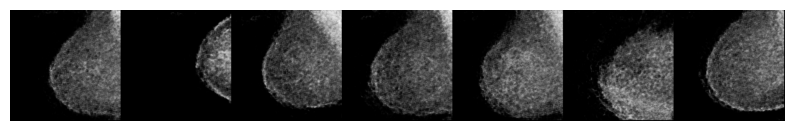

[Epoch 71/200] [D loss: -36.802925] [G loss: -31.849846]
[Epoch 72/200] [D loss: -42.469368] [G loss: -26.636757]
[Epoch 73/200] [D loss: -43.633831] [G loss: -24.363857]
[Epoch 74/200] [D loss: -31.678606] [G loss: -18.236979]
[Epoch 75/200] [D loss: -25.205238] [G loss: -33.987942]
Generated images shape: torch.Size([7, 1, 256, 256])


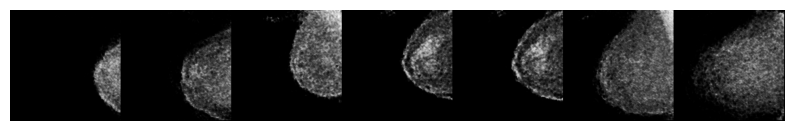

[Epoch 76/200] [D loss: -42.048252] [G loss: -11.981405]
[Epoch 77/200] [D loss: -35.227764] [G loss: -24.780300]
[Epoch 78/200] [D loss: -36.630871] [G loss: -17.167290]
[Epoch 79/200] [D loss: -29.524281] [G loss: -31.447926]
[Epoch 80/200] [D loss: -24.719734] [G loss: -25.287025]
Generated images shape: torch.Size([7, 1, 256, 256])


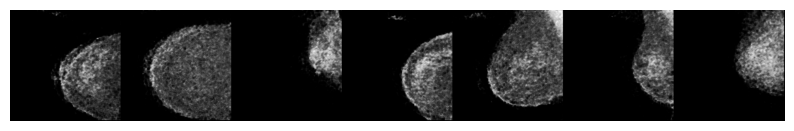

[Epoch 81/200] [D loss: -42.466969] [G loss: -14.013183]
[Epoch 82/200] [D loss: -34.569721] [G loss: -13.690580]
[Epoch 83/200] [D loss: -39.796448] [G loss: -26.938723]
[Epoch 84/200] [D loss: -31.011135] [G loss: -25.230940]
[Epoch 85/200] [D loss: -36.786018] [G loss: -0.781645]
Generated images shape: torch.Size([7, 1, 256, 256])


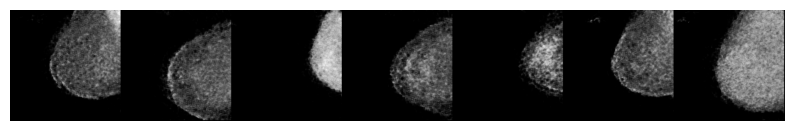

[Epoch 86/200] [D loss: -35.937199] [G loss: -32.882671]
[Epoch 87/200] [D loss: -35.384003] [G loss: -27.039944]
[Epoch 88/200] [D loss: -38.512421] [G loss: -32.266251]
[Epoch 89/200] [D loss: -24.753834] [G loss: -9.231971]


In [ ]:
import torch
from torch.autograd import Variable
import numpy as np
import os

from google.colab import drive
drive.mount('/content/drive')  # Mount Google Drive

# Define save directory inside Google Drive
save_dir = "/content/drive/My Drive/GAN_Weights"
os.makedirs(save_dir, exist_ok=True)  # Create directory if it doesn't exist

checkpoint_interval = 10

# Set the device to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Image shape and model setup
img_shape = (1, img_size, img_size)

# Instantiate models and move them to the GPU
generator = Generator(latent_dim=latent_dim, img_shape=img_shape).to(device)
discriminator = Discriminator(img_shape=img_shape).to(device)

# Define optimizers
optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr_g, betas=(b1, b2))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr_d, betas=(b1, b2))

# Learning Rate Scheduler (Cosine Annealing)
scheduler_G = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_G, T_max=n_epochs)
scheduler_D = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_D, T_max=n_epochs)

# Gradient penalty function
def compute_gradient_penalty(D, real_samples, fake_samples):
    """Calculates the gradient penalty loss for WGAN GP"""
    alpha = torch.tensor(np.random.random((real_samples.size(0), 1, 1, 1)), dtype=torch.float32, device=device)
    interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True)
    d_interpolates = D(interpolates)

    fake = Variable(torch.ones(real_samples.shape[0], 1, dtype=torch.float32, device=device), requires_grad=False)

    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

# ----------
#  Training
# ----------

batches_done = 0
d_loss_val = 0
g_loss_val = 0

for epoch in range(1, n_epochs + 1):
    if epoch % 5 == 1:
        generate_and_display_images(generator, num_images=7, latent_dim=latent_dim, nrow=7, device=device)
    for i, imgs in enumerate(dataloader):

        # Ensure the tensors are float32 and move to device
        real_imgs = Variable(imgs.type(torch.float32).to(device))

        # ---------------------
        #  Train Discriminator
        # ---------------------

        optimizer_D.zero_grad()

        # Sample noise as generator input
        z = Variable(torch.tensor(np.random.normal(0, 1, (imgs.shape[0], latent_dim)), dtype=torch.float32).to(device))

        # Generate a batch of images
        fake_imgs = generator(z)

        # Reshape fake images to match the shape of real images
        fake_imgs = fake_imgs.view(fake_imgs.size(0), 1, img_size, img_size)

        # Real images
        real_validity = discriminator(real_imgs)
        # Fake images
        fake_validity = discriminator(fake_imgs)
        # Gradient penalty
        gradient_penalty = compute_gradient_penalty(discriminator, real_imgs.data, fake_imgs.data)
        # Adversarial loss
        d_loss = -torch.mean(real_validity) + torch.mean(fake_validity) + lambda_gp * gradient_penalty

        # Apply gradient clipping
        torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=1.0)

        # Backprop and optimizer step
        d_loss.backward()
        d_loss_val = d_loss.item()

        optimizer_D.step()

        optimizer_G.zero_grad()

        # Train the generator every n_critic steps
        if i % n_critic == 0:

            # -----------------
            #  Train Generator
            # -----------------

            # Generate a batch of images
            fake_imgs = generator(z)

            # Reshape fake images to match the shape of real images
            fake_imgs = fake_imgs.view(fake_imgs.size(0), 1, img_size, img_size)

            # Loss measures generator's ability to fool the discriminator
            # Train on fake images
            fake_validity = discriminator(fake_imgs)
            g_loss = -torch.mean(fake_validity)

            # Apply gradient clipping
            torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=1.0)

            # Backprop and optimizer step
            g_loss.backward()
            optimizer_G.step()

            g_loss_val = g_loss.item()

            if batches_done % sample_interval == 0:
                save_image(fake_imgs.data[:25], "images/%d.png" % batches_done, nrow=5, normalize=True)

            batches_done += 1

        # Step the schedulers (learning rate adjustment)
        scheduler_G.step()
        scheduler_D.step()

    print("[Epoch %d/%d] [D loss: %f] [G loss: %f]"
          % (epoch, n_epochs, d_loss_val, g_loss_val))

# -----------------------
#  Save Model to Drive
# -----------------------

generator_path = os.path.join(save_dir, "generator_final.pth")
discriminator_path = os.path.join(save_dir, "discriminator_final.pth")

torch.save(generator.state_dict(), generator_path)
torch.save(discriminator.state_dict(), discriminator_path)

print(f"Model saved to Google Drive at:\n{generator_path}\n{discriminator_path}")

# ----------------------------
#  Generate and Save Images
# ----------------------------
num_samples = 10  # Number of images to save at the end
z = torch.randn(num_samples, latent_dim, device=device)  # Generate latent vectors
final_images = generator(z).view(num_samples, 1, img_size, img_size)  # Reshape output

# Save each image to Google Drive
for i in range(num_samples):
    save_path = os.path.join(image_save_dir, f"generated_image_{i+1}.png")
    save_image(final_images[i], save_path, normalize=True)

print(f"Final generated images saved to Google Drive at: {image_save_dir}")